# 3.2 - EWC (Elastic Weight Consolidation)

- Before learning a new task, measure which
weights mattered for the old tasks (the Fisher information) and add a penalty that
holds those weights near their old values. Costs no stored data only the Fisher
diagonal and a copy of the weights.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token


if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

Group-disjoint clips for all three tasks

In [5]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [6]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [7]:
# TASK 1
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [8]:
# TASK 2
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [9]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [10]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']


In [11]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14}


## **Create Loaders**

EWC needs the OLD task's train set (for the Fisher) and its val set (to watch retention), so base train / val loaders are built too.

In [ ]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_val   = UCF101Clips(os.path.join(cfg.BASE_ROOT, "val"),   class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

base_train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
base_val_loader   = DataLoader(base_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
base_test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

Load the ResNet50 teacher from notebook 2, then grow the head to cover Task 1.

In [13]:
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
model = unfreeze_all(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


In [14]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

In [15]:
snapshots = []
results_baseline = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_baseline)

  base             -> Acc=0.9387  Loss=0.1979
  task1_only        -> Acc=0.0000  Loss=4.4398
  combined_t1       -> Acc=0.6180  Loss=1.6470


In [ ]:
print(f"classifier: in={model.fc.in_features}  out={model.fc.out_features}")

classifier: in=256  out=15


## **Task One**

Anchor and Fisher come from the base task, then Task 1 is trained with the EWC penalty. The printout shows new-task and base val accuracy each epoch.

In [17]:
star_base   = theta_star(model)
fisher_base = get_fisher(base_train_loader, model, device)

In [18]:
set_seed(cfg.SEED)
train_task1 = train_ewc(model, task1_train_loader, task1_val_loader, base_val_loader,
                        star_base, fisher_base, device,
                        num_epochs=cfg.EWC_EPOCHS, lr=cfg.EWC_LR, ewc_lambda=cfg.EWC_LAMBDA)

Epoch [1/10] | Train Acc: 0.0000 | New Val: 0.0000 | Old Val: 0.8606


Epoch [2/10] | Train Acc: 0.0325 | New Val: 0.0548 | Old Val: 0.8424


Epoch [3/10] | Train Acc: 0.3449 | New Val: 0.2740 | Old Val: 0.8606


Epoch [4/10] | Train Acc: 0.6833 | New Val: 0.5616 | Old Val: 0.8667


Epoch [5/10] | Train Acc: 0.8590 | New Val: 0.7123 | Old Val: 0.8182


Epoch [6/10] | Train Acc: 0.9154 | New Val: 0.7260 | Old Val: 0.8303


Epoch [7/10] | Train Acc: 0.9718 | New Val: 0.8356 | Old Val: 0.7455


Epoch [8/10] | Train Acc: 0.9761 | New Val: 0.8219 | Old Val: 0.7152


Epoch [9/10] | Train Acc: 0.9848 | New Val: 0.8767 | Old Val: 0.7455


Epoch [10/10] | Train Acc: 0.9892 | New Val: 0.8904 | Old Val: 0.6909


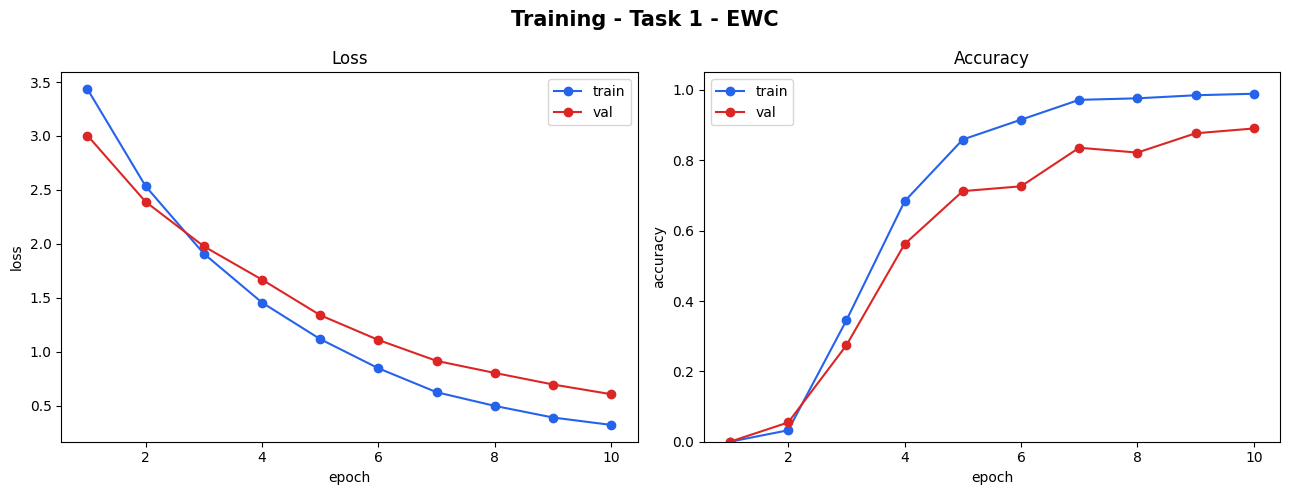

In [19]:
plot_training_results(train_task1, task_name="Task 1 - EWC")

In [20]:
results_after_t1 = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_after_t1)

  base             -> Acc=0.6745  Loss=0.9381
  task1_only        -> Acc=0.9636  Loss=0.4985
  combined_t1       -> Acc=0.7733  Loss=0.7879


Test Accuracy: 0.7733


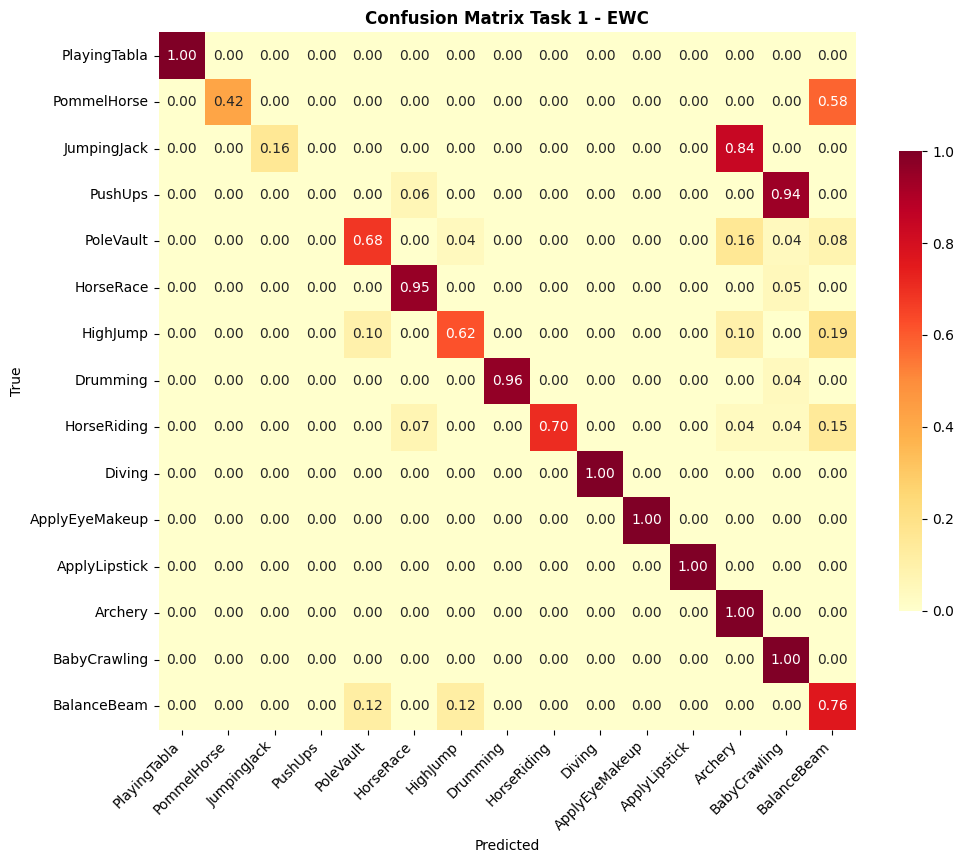

In [21]:
_, all_preds, all_labels = test_model(model, combined_test_loader, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 1 - EWC")

In [ ]:
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, len(cfg.SELECTED_CLASSES)),
                       split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)))


METRICS FOR 15 CLASSES
  Accuracy : 0.7733
  F1-Score : 0.7504

PER-CLASS REPORT
                precision    recall  f1-score   support

  PlayingTabla       1.00      1.00      1.00        17
   PommelHorse       1.00      0.42      0.59        19
   JumpingJack       1.00      0.16      0.27        19
       PushUps       0.00      0.00      0.00        16
     PoleVault       0.81      0.68      0.74        25
     HorseRace       0.86      0.95      0.90        20
      HighJump       0.81      0.62      0.70        21
      Drumming       1.00      0.96      0.98        25
   HorseRiding       1.00      0.70      0.83        27
        Diving       1.00      1.00      1.00        23
ApplyEyeMakeup       1.00      1.00      1.00        25
 ApplyLipstick       1.00      1.00      1.00        20
       Archery       0.52      1.00      0.68        25
  BabyCrawling       0.55      1.00      0.71        23
   BalanceBeam       0.38      0.76      0.51        17

      accuracy      

## **Task 2**

In [ ]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


In [24]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test2        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [25]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

Now the old task is base + Task 1, so the anchor and Fisher are measured over both.

In [26]:
old_train        = ConcatDataset([base_train, task1_train])
old_train_loader = DataLoader(old_train, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2)
old_val          = ConcatDataset([base_val, task1_val])
old_val_loader   = DataLoader(old_val, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

star_t1   = theta_star(model)
fisher_t1 = get_fisher(old_train_loader, model, device)

In [27]:
results_baseline_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                         [task1_test_loader, task2_test_loader],
                                         [combined_test_loader, combined_test_loader2])

  base             -> Acc=0.8113  Loss=0.7254
  task1_only        -> Acc=0.8727  Loss=0.6818
  task2_only        -> Acc=0.0000  Loss=4.0014
  combined_t1       -> Acc=0.8323  Loss=0.7105
  combined_t2       -> Acc=0.6105  Loss=1.5876


In [28]:
set_seed(cfg.SEED)
train_task2 = train_ewc(model, task2_train_loader, task2_val_loader, old_val_loader,
                        star_t1, fisher_t1, device,
                        num_epochs=cfg.EWC_EPOCHS, lr=cfg.EWC_LR, ewc_lambda=cfg.EWC_LAMBDA)

Epoch [1/10] | Train Acc: 0.0000 | New Val: 0.0000 | Old Val: 0.7185


Epoch [2/10] | Train Acc: 0.0915 | New Val: 0.1647 | Old Val: 0.6765


Epoch [3/10] | Train Acc: 0.5885 | New Val: 0.5765 | Old Val: 0.6261


Epoch [4/10] | Train Acc: 0.8569 | New Val: 0.7765 | Old Val: 0.5756


Epoch [5/10] | Train Acc: 0.9324 | New Val: 0.8353 | Old Val: 0.5210


Epoch [6/10] | Train Acc: 0.9543 | New Val: 0.9529 | Old Val: 0.5042


Epoch [7/10] | Train Acc: 0.9503 | New Val: 0.9412 | Old Val: 0.4454


Epoch [8/10] | Train Acc: 0.9861 | New Val: 0.9882 | Old Val: 0.4286


Epoch [9/10] | Train Acc: 0.9821 | New Val: 1.0000 | Old Val: 0.4118


Epoch [10/10] | Train Acc: 0.9940 | New Val: 1.0000 | Old Val: 0.3908


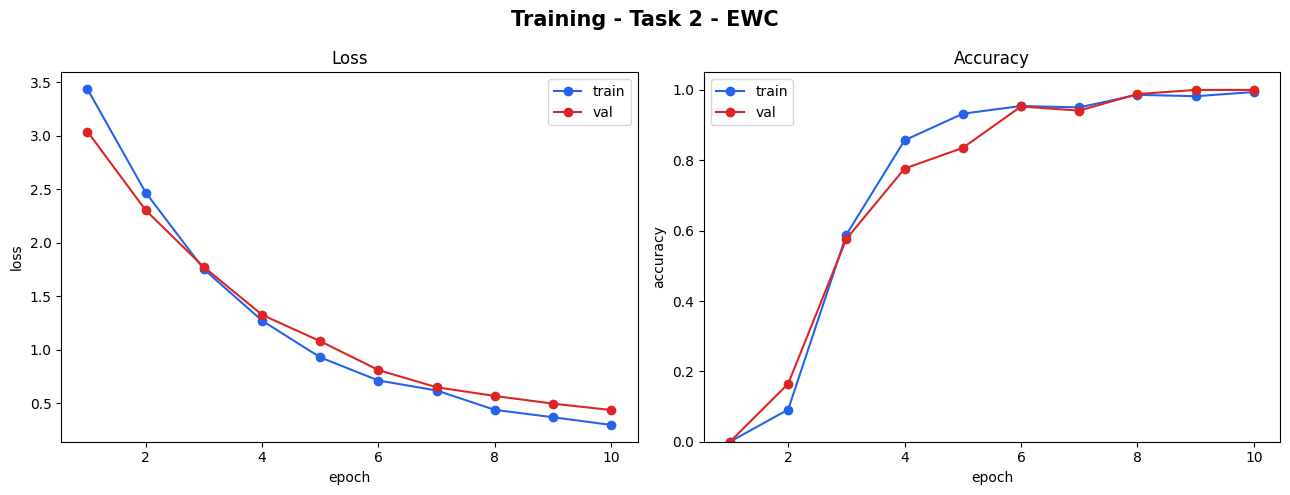

In [29]:
plot_training_results(train_task2, task_name="Task 2 - EWC")

In [30]:
results_after_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                      [task1_test_loader, task2_test_loader],
                                      [combined_test_loader, combined_test_loader2])
snapshots.append(results_after_t2)

  base             -> Acc=0.4670  Loss=1.5884
  task1_only        -> Acc=0.1818  Loss=2.8254
  task2_only        -> Acc=0.9487  Loss=0.4137
  combined_t1       -> Acc=0.3696  Loss=2.0110
  combined_t2       -> Acc=0.5239  Loss=1.5853


Test Accuracy: 0.5239


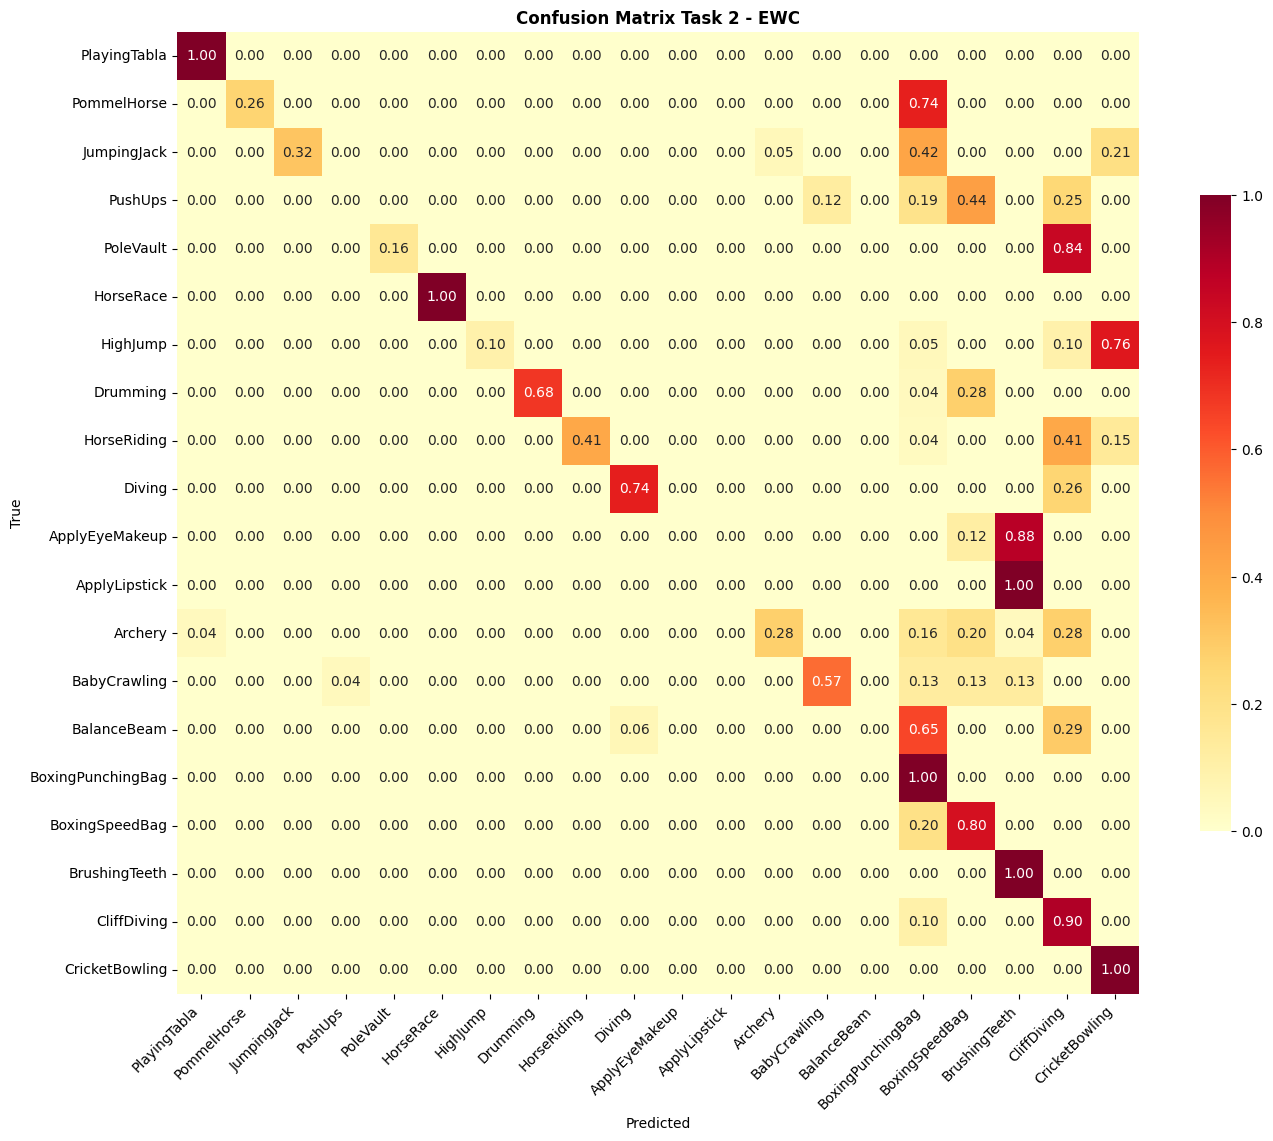

In [31]:
_, all_preds, all_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 2 - EWC")

In [32]:
split_new = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_new),
                       split_new=(split_new, len(ALL_CLASSES_LIST)))


METRICS FOR 20 CLASSES
  Accuracy : 0.5239
  F1-Score : 0.4712

PER-CLASS REPORT
                   precision    recall  f1-score   support

     PlayingTabla       0.94      1.00      0.97        17
      PommelHorse       1.00      0.26      0.42        19
      JumpingJack       1.00      0.32      0.48        19
          PushUps       0.00      0.00      0.00        16
        PoleVault       1.00      0.16      0.28        25
        HorseRace       1.00      1.00      1.00        20
         HighJump       1.00      0.10      0.17        21
         Drumming       1.00      0.68      0.81        25
      HorseRiding       1.00      0.41      0.58        27
           Diving       0.94      0.74      0.83        23
   ApplyEyeMakeup       0.00      0.00      0.00        25
    ApplyLipstick       0.00      0.00      0.00        20
          Archery       0.88      0.28      0.42        25
     BabyCrawling       0.87      0.57      0.68        23
      BalanceBeam       0.00    

## **Forgetting**

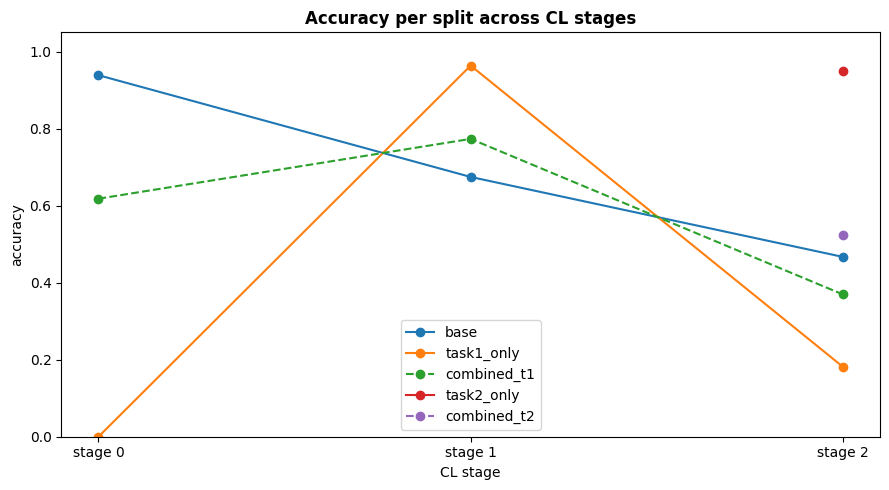

In [33]:
plot_cl_forgetting(snapshots)

## **Save**

In [34]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"arm": "ewc", "classes": ALL_CLASSES_LIST, "snapshots": snapshots}
with open(f"{cfg.RESULTS_DIR}/stage3_ewc.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage3_ewc.json")

saved -> /content/drive/MyDrive/apai/results/stage3_ewc.json
